# Rental Pricing Dataset, Malaysia

Dataset Link: https://www.kaggle.com/datasets/ariewijaya/rent-pricing-kuala-lumpur-malaysi

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv("mudah-apartment-kl-selangor.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19991 entries, 0 to 19990
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ads_id                 19991 non-null  int64  
 1   prop_name              19043 non-null  object 
 2   completion_year        10806 non-null  float64
 3   monthly_rent           19989 non-null  object 
 4   location               19991 non-null  object 
 5   property_type          19991 non-null  object 
 6   rooms                  19985 non-null  object 
 7   parking                14289 non-null  float64
 8   bathroom               19985 non-null  float64
 9   size                   19991 non-null  object 
 10  furnished              19986 non-null  object 
 11  facilities             17782 non-null  object 
 12  additional_facilities  14043 non-null  object 
 13  region                 19991 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 2.1+

In [4]:
df.head()

,ads_id,prop_name,completion_year,monthly_rent,location,property_type,rooms,parking,bathroom,size,furnished,facilities,additional_facilities,region
0,100323185,The Hipster @ Taman Desa,2022.0,RM 4 200 per month,Kuala Lumpur - Taman Desa,Condominium,5,2.0,6.0,1842 sq.ft.,Fully Furnished,"Minimart, Gymnasium, Security, Playground, Swimming Pool, Parking, Lift, Barbeque area, Multipurpose hall, Jogging Track","Air-Cond, Cooking Allowed, Washing Machine",Kuala Lumpur
1,100203973,Segar Courts,NaN,RM 2 300 per month,Kuala Lumpur - Cheras,Condominium,3,1.0,2.0,1170 sq.ft.,Partially Furnished,"Playground, Parking, Barbeque area, Security, Jogging Track, Swimming Pool, Gymnasium, Lift, Sauna","Air-Cond, Cooking Allowed, Near KTM/LRT",Kuala Lumpur
2,100323128,Pangsapuri Teratak Muhibbah 2,NaN,RM 1 000 per month,Kuala Lumpur - Taman Desa,Apartment,3,NaN,2.0,650 sq.ft.,Fully Furnished,"Minimart, Jogging Track, Lift, Swimming Pool",NaN,Kuala Lumpur
3,100191767,Sentul Point Suite Apartment,2020.0,RM 1 700 per month,Kuala Lumpur - Sentul,Apartment,2,1.0,2.0,743 sq.ft.,Partially Furnished,"Parking, Playground, Swimming Pool, Squash Court, Security, Minimart, Gymnasium, Lift","Cooking Allowed, Near KTM/LRT, Washing Machine",Kuala Lumpur
4,97022692,Arte Mont Kiara,NaN,RM 1 299 per month,Kuala Lumpur - Mont Kiara,Service Residence,1,1.0,1.0,494 sq.ft.,Not Furnished,"Parking, Security, Lift, Swimming Pool, Playground, Gymnasium, Barbeque area, Minimart, Multipurpose hall, Club house, Jogging Track",Air-Cond,Kuala Lumpur


### Data Cleaning

In [5]:
df = df.drop(columns=["ads_id"], axis=1)

In [6]:
# Strip text from the rental price
df['monthly_rent'] = (
    df['monthly_rent']
    .str.replace('RM', '', regex=False)
    .str.replace('per month', '', regex=False)
    .str.replace(' ', '', regex=False)
)

df['monthly_rent'] = pd.to_numeric(df['monthly_rent'], errors='coerce')

In [8]:
# Fill missing parking counts with 1 if facilities mention parking
mask = (
    df['parking'].isna() &
    df['facilities'].str.lower().str.contains('parking', na=False)
)

df.loc[mask, 'parking'] = 1
print(f'Total rows filled with 1 for parking field {mask.sum()}')
print(f'Parking with NULL Values {df['parking'].isna().sum()}')

Total rows filled with 1 for parking field 3754
Parking with NULL Values 1948


In [9]:
# Drop the 'Kuala Lumput -' from the location field
df['location'] = df['location'].str.replace(r'^(Kuala Lumpur|Selangor)\s*-\s*', '', regex=True)
print(df['location'].nunique())

129


In [10]:
# Drop the sq.ft. from size
df["size"] = df["size"].str.extract(r"(\d+)").astype(int)

In [11]:
# Encode furnished into one-hot encodings
df["fully_furnished"] = (
    df["furnished"]
    .str.strip()
    .str.lower()
    .eq("fully furnished")
    .astype(int)
)
df = df.drop(columns=["furnished"])

In [12]:
# Convert year information into age
# 2023 is used as the dataset was scrapped in that year
current_year = 2023
df["property_age"] = current_year - df["completion_year"]
df = df.drop(columns=["completion_year"], axis=1)

In [13]:
# Map region data into one-hot encodings 
df = pd.get_dummies(df, columns=["region"], dtype=int)

In [14]:
# Convert facilities data into one hot encodings
facilities_one_hot = df["facilities"].str.get_dummies(sep=", ")
facilities_one_hot = facilities_one_hot.drop(columns=["10", "11", "6"], axis=1)

additional_facilities_one_hot = df["additional_facilities"].str.get_dummies(sep=", ")

df = df.join(facilities_one_hot)
df = df.join(additional_facilities_one_hot)
df = df.drop(columns=["facilities", "additional_facilities"], axis=1)

In [15]:
df.head()

,prop_name,monthly_rent,location,property_type,rooms,parking,bathroom,size,fully_furnished,property_age,region_Kuala Lumpur,region_Selangor,Barbeque area,Club house,Gymnasium,Jogging Track,Lift,Minimart,Multipurpose hall,Parking,Playground,Sauna,Security,Squash Court,Swimming Pool,Tennis Court,Air-Cond,Cooking Allowed,Internet,Near KTM/LRT,Washing Machine
0,The Hipster @ Taman Desa,4200.0,Taman Desa,Condominium,5,2.0,6.0,1842,1,1.0,1,0,1,0,1,1,1,1,1,1,1,0,1,0,1,0,1,1,0,0,1
1,Segar Courts,2300.0,Cheras,Condominium,3,1.0,2.0,1170,0,NaN,1,0,1,0,1,1,1,0,0,1,1,1,1,0,1,0,1,1,0,1,0
2,Pangsapuri Teratak Muhibbah 2,1000.0,Taman Desa,Apartment,3,NaN,2.0,650,1,NaN,1,0,0,0,0,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0
3,Sentul Point Suite Apartment,1700.0,Sentul,Apartment,2,1.0,2.0,743,0,3.0,1,0,0,0,1,0,1,1,0,1,1,0,1,1,1,0,0,1,0,1,1
4,Arte Mont Kiara,1299.0,Mont Kiara,Service Residence,1,1.0,1.0,494,0,NaN,1,0,1,1,1,1,1,1,1,1,1,0,1,0,1,0,1,0,0,0,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19991 entries, 0 to 19990
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   prop_name            19043 non-null  object 
 1   monthly_rent         19989 non-null  float64
 2   location             19991 non-null  object 
 3   property_type        19991 non-null  object 
 4   rooms                19985 non-null  object 
 5   parking              18043 non-null  float64
 6   bathroom             19985 non-null  float64
 7   size                 19991 non-null  int64  
 8   fully_furnished      19991 non-null  int64  
 9   property_age         10806 non-null  float64
 10  region_Kuala Lumpur  19991 non-null  int64  
 11  region_Selangor      19991 non-null  int64  
 12  Barbeque area        19991 non-null  int64  
 13  Club house           19991 non-null  int64  
 14  Gymnasium            19991 non-null  int64  
 15  Jogging Track        19991 non-null 

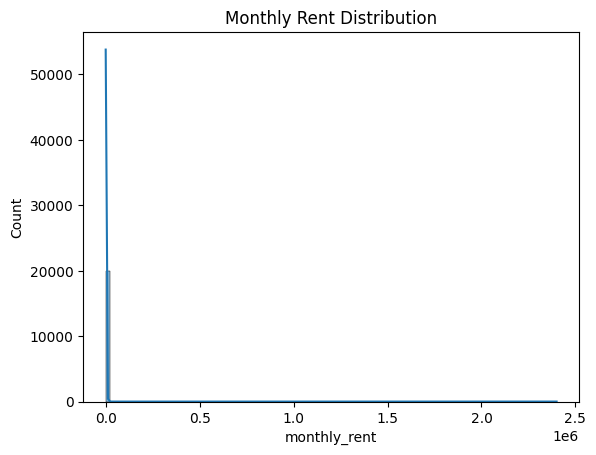

In [22]:
sns.histplot(df["monthly_rent"], bins=100, kde=True)
plt.title("Monthly Rent Distribution")
plt.show()